# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv(r"C:\Users\User\Desktop\DATA LOVES ACADEMY\DATA\yulu_rental.csv")
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

In [35]:
df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,weekday,weekday_num,week,year,day
datetime,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,1,0,Saturday,5,52,2011,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,1,1,Saturday,5,52,2011,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,1,2,Saturday,5,52,2011,1
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,1,3,Saturday,5,52,2011,1
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,1,4,Saturday,5,52,2011,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,12,19,Wednesday,2,51,2012,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,12,20,Wednesday,2,51,2012,19
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,12,21,Wednesday,2,51,2012,19


## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [6]:
monthly_avg_rent = df['count'].resample('ME').mean()


<Axes: title={'center': 'Середня кількість оренд на місяць'}, xlabel='Місяці', ylabel='Кількість оренд'>

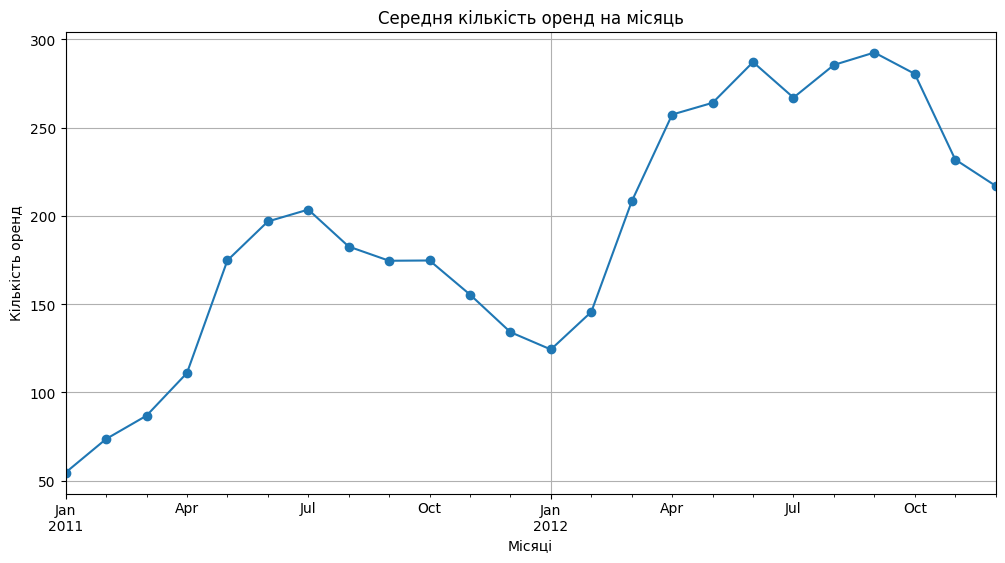

In [8]:
#Графік Pandas

monthly_avg_rent.plot(
    marker = 'o',
    figsize=(12,6),
    title='Середня кількість оренд на місяць',
    xlabel='Місяці',
    ylabel='Кількість оренд',
    grid=True
)

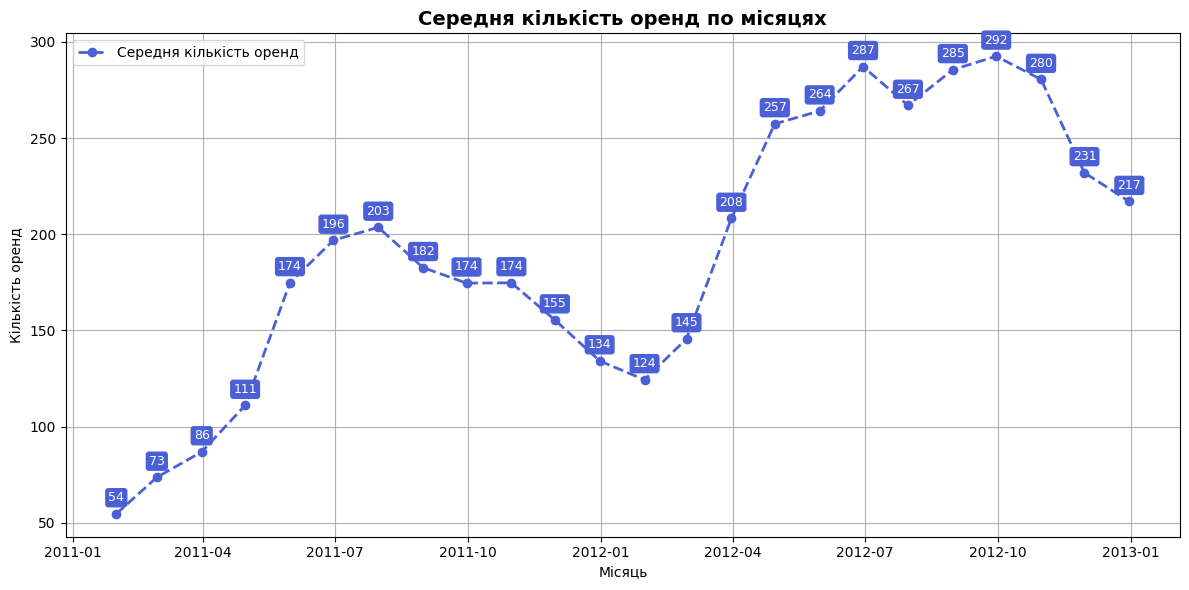

In [16]:
# Matplotlib

plt.figure(figsize=(12, 6))
plt.plot(
    monthly_avg_rent,
    color='#4B60D7',
    marker='o',
    linestyle='--',
    linewidth=2,
    label='Середня кількість оренд'
)

plt.title('Середня кількість оренд по місяцях', fontsize=14, weight='bold')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренд')

plt.legend()
plt.grid(True)

# Додаємо підписи до кожної точки
for x, y in zip(monthly_avg_rent.index, monthly_avg_rent.values):
    plt.text(
        x, y + 5,               # трохи вище точки
        f'{int(y)}',            # текст підпису
        ha='center',            # вирівнювання по центру
        va='bottom',
        fontsize=9,
        color='white',
        bbox=dict(
            facecolor='#4B60D7',
            edgecolor='#4B60D7',
            boxstyle='round,pad=0.2'
        )
    )
plt.tight_layout()
plt.show()

**ВИСНОВОК.** 

Для першого графіку треба менше коду. Другий подобається візуально більше. Різниця в сітці, позначках осі Х, початковій і кінцевій точках на графіку.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [18]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень2

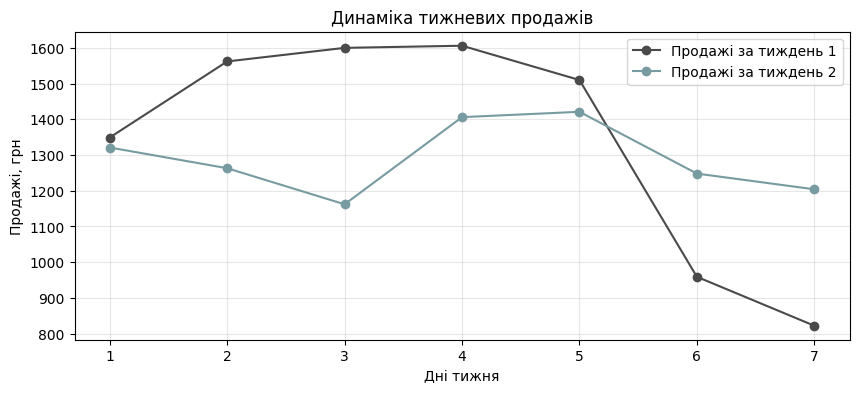

In [24]:
plt.figure(figsize=(10,4))

plt.plot(days, sales_week1, label='Продажі за тиждень 1', marker='o', color='#4a4a4a')
plt.plot(days, sales_week2, label='Продажі за тиждень 2', marker='o', color='#789ba1')
plt.title('Динаміка тижневих продажів')
plt.xlabel('Дні тижня')
plt.ylabel('Продажі, грн')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [32]:
for i, sales in enumerate([sales_week1, sales_week2], start=1):
    mean = np.mean(sales)
    std = np.std(sales, ddof=1)   # вибіркове стандартне відхилення
    value_range = np.max(sales) - np.min(sales)
    cv = std / mean * 100

    print(f"Тиждень {i}")
    print(f"Середнє: {mean:.2f}")
    print(f"Стандартне відхилення: {std:.2f}")
    print(f"Розмах: {value_range}")
    print(f"Коефіцієнт варіації: {cv:.2f}%")
    print('='*30)

Тиждень 1
Середнє: 1344.00
Стандартне відхилення: 324.04
Розмах: 784
Коефіцієнт варіації: 24.11%
Тиждень 2
Середнє: 1289.29
Стандартне відхилення: 98.19
Розмах: 259
Коефіцієнт варіації: 7.62%


**Продажі у другому тижні були стабільнішими, оскільки їх коливання менші. Це видно не лише з графіка, а й з обчислень**

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

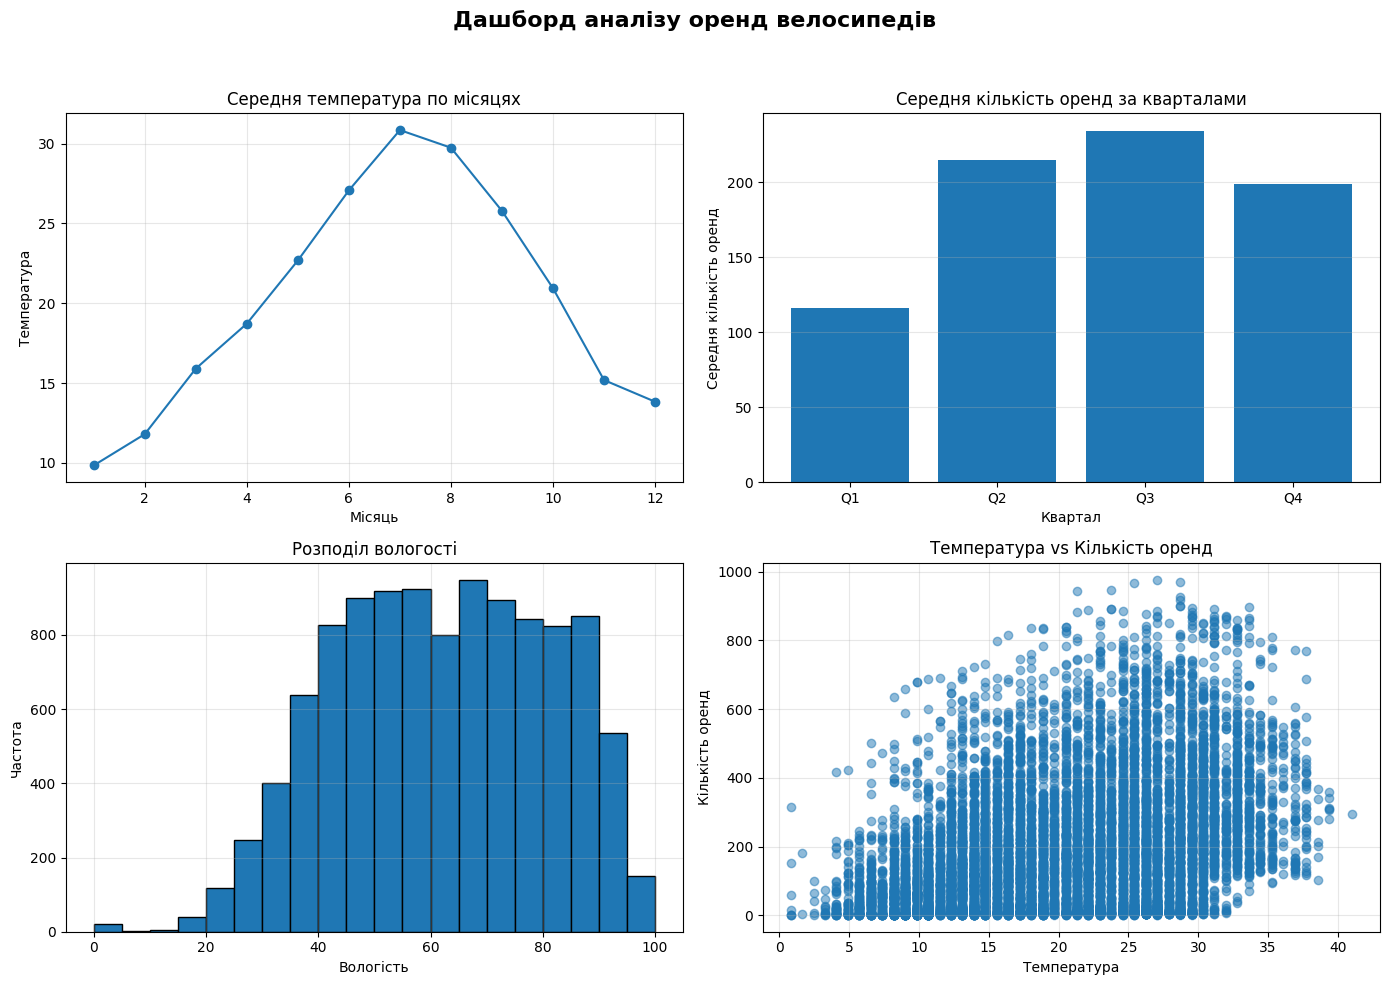

In [45]:
monthly_avg_temp = df.groupby('month')['temp'].mean()
season_avg_rent = df.groupby('season')['count'].mean()
humidity_all = df['humidity']
temp_values = df['temp']
count_values = df['count']

plt.figure(figsize=(14, 10))

# Графік 1: середня температура по місяцях
plt.subplot(2, 2, 1)
plt.plot(monthly_avg_temp.index, monthly_avg_temp.values, marker='o')
plt.title('Середня температура по місяцях')
plt.xlabel('Місяць')
plt.ylabel('Температура')
plt.grid(True, alpha=0.3)

# Графік 2: середня кількість оренд за кварталами
plt.subplot(2, 2, 2)
plt.bar(season_avg_rent.index, season_avg_rent.values)
plt.title('Середня кількість оренд за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Середня кількість оренд')
plt.xticks([1, 2, 3, 4], ['Q1', 'Q2', 'Q3', 'Q4'])
plt.grid(True, axis='y', alpha=0.3)

# Графік 3: гістограма вологості
plt.subplot(2, 2, 3)
plt.hist(humidity_all, bins=20, edgecolor='black')
plt.title('Розподіл вологості')
plt.xlabel('Вологість')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)

# Графік 4: температура vs кількість оренд
plt.subplot(2, 2, 4)
plt.scatter(temp_values, count_values, alpha=0.5)
plt.title('Температура vs Кількість оренд')
plt.xlabel('Температура')
plt.ylabel('Кількість оренд')
plt.grid(True, alpha=0.3)

# Дашборд
plt.suptitle('Дашборд аналізу оренд велосипедів', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

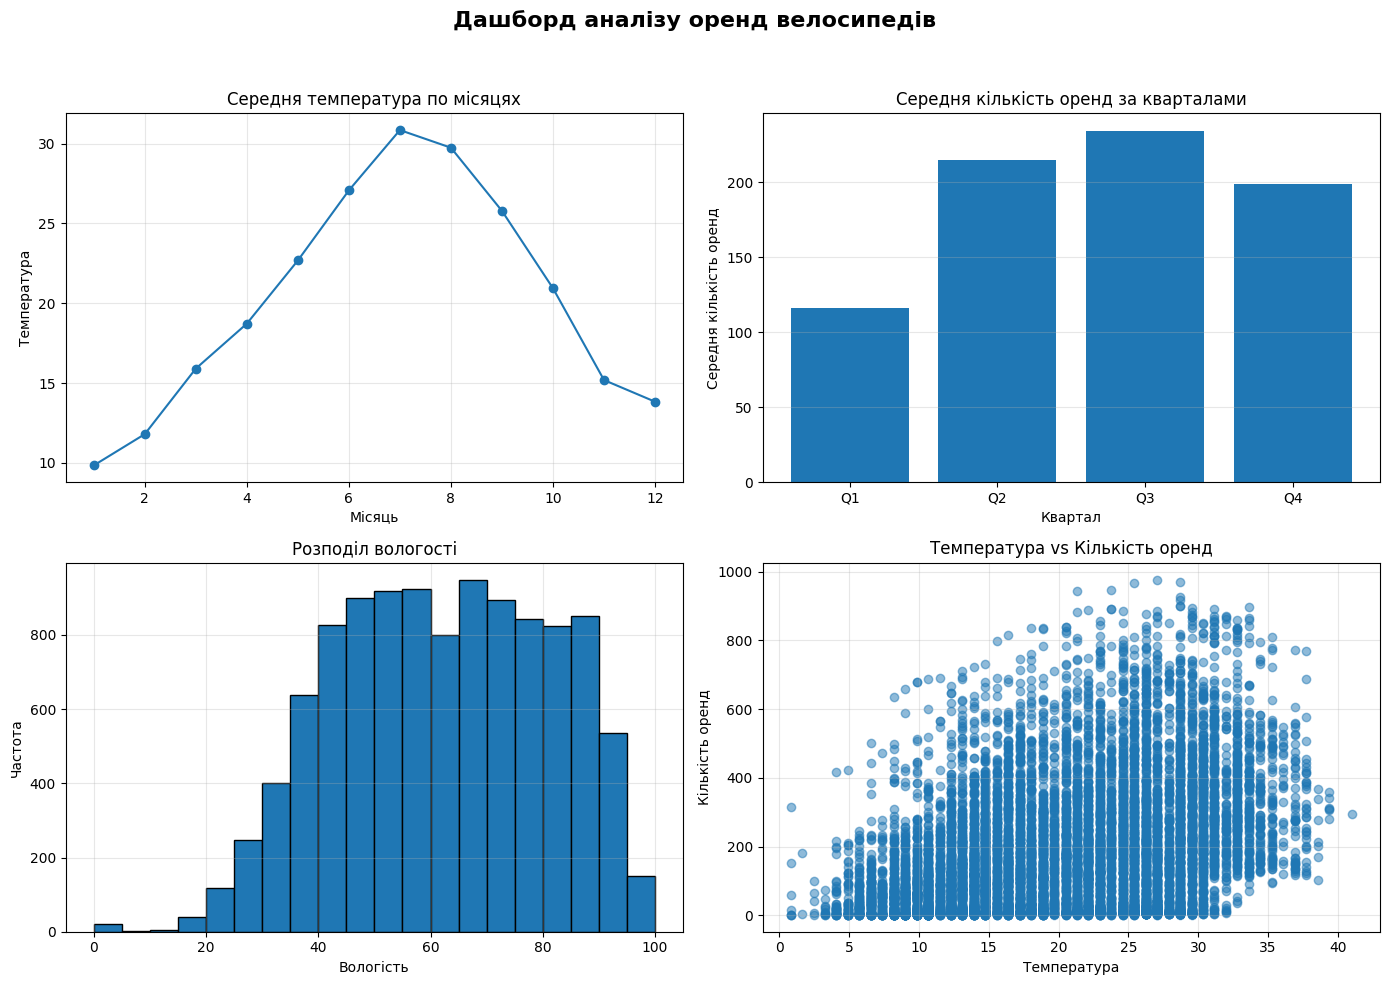

In [46]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# Графік 1: середня температура по місяцях
ax[0, 0].plot(monthly_avg_temp.index, monthly_avg_temp.values, marker='o')
ax[0, 0].set_title('Середня температура по місяцях')
ax[0, 0].set_xlabel('Місяць')
ax[0, 0].set_ylabel('Температура')
ax[0, 0].grid(True, alpha=0.3)

# Графік 2: середня кількість оренд за кварталами
ax[0, 1].bar(season_avg_rent.index, season_avg_rent.values)
ax[0, 1].set_title('Середня кількість оренд за кварталами')
ax[0, 1].set_xlabel('Квартал')
ax[0, 1].set_ylabel('Середня кількість оренд')
ax[0, 1].set_xticks([1, 2, 3, 4])
ax[0, 1].set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
ax[0, 1].grid(True, axis='y', alpha=0.3)

# Графік 3: гістограма вологості
ax[1, 0].hist(humidity_all, bins=20, edgecolor='black')
ax[1, 0].set_title('Розподіл вологості')
ax[1, 0].set_xlabel('Вологість')
ax[1, 0].set_ylabel('Частота')
ax[1, 0].grid(True, alpha=0.3)

# Графік 4: температура vs кількість оренд
ax[1, 1].scatter(temp_values, count_values, alpha=0.5)
ax[1, 1].set_title('Температура vs Кількість оренд')
ax[1, 1].set_xlabel('Температура')
ax[1, 1].set_ylabel('Кількість оренд')
ax[1, 1].grid(True, alpha=0.3)

# Дашборд
fig.suptitle('Дашборд аналізу оренд велосипедів', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

В обох підходах код краще писати блоками: окремий блок для кожного графіка. plt.subplots() не робить код автоматично читабельним, але дає явне звернення до конкретної осі через ax[i, j]. Завдяки цьому менше ризик випадково застосувати підпис або налаштування не до того графіка, як це може трапитися при роботі через активний subplot у plt.subplot().

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

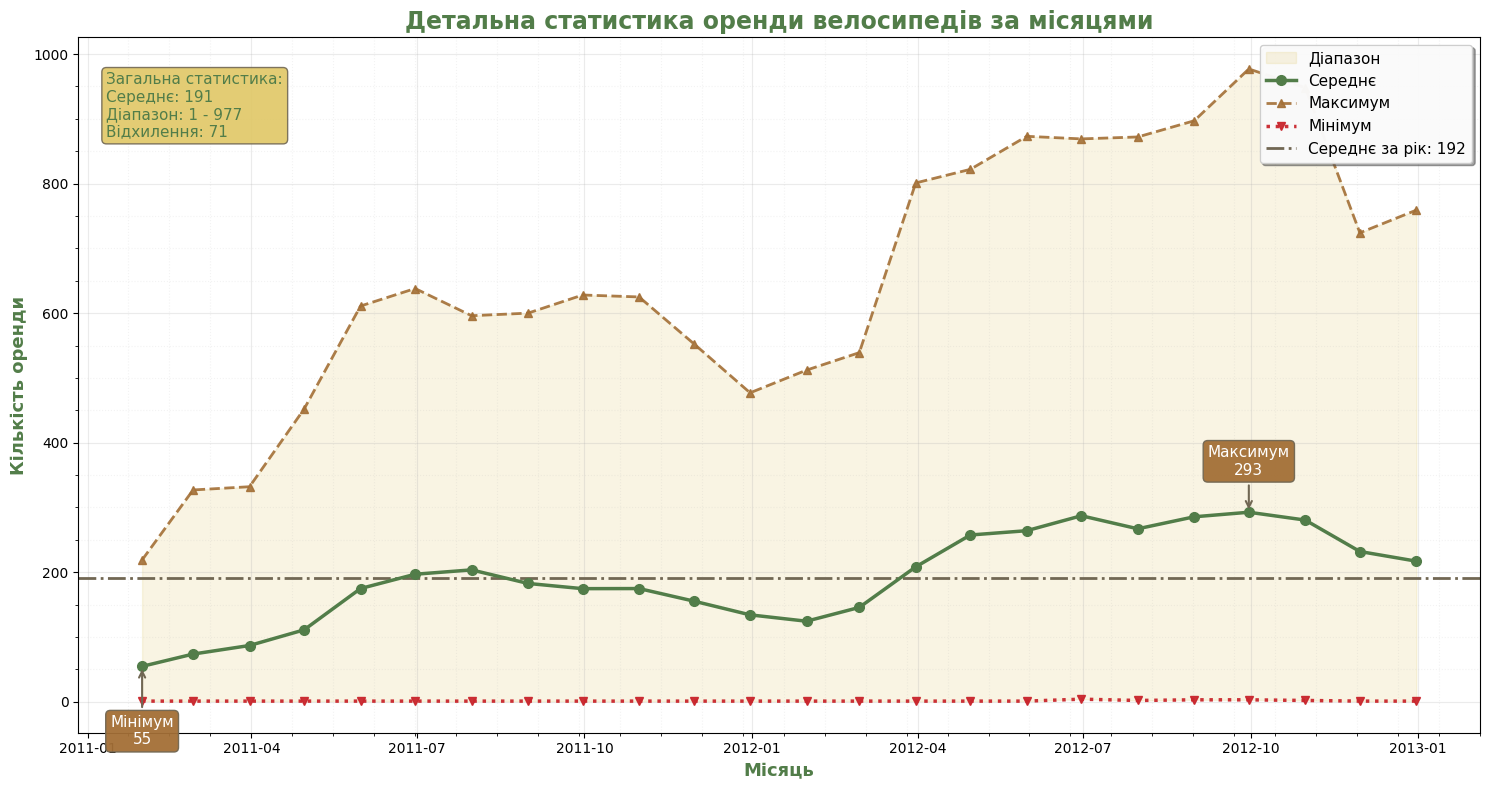

In [59]:
# Місячна статистика по кількості оренд
monthly_stats = df['count'].resample('ME').agg(['mean', 'max', 'min'])

# Загальне середнє за весь період
overall_mean = df['count'].mean()

# Додаткова статистика для текстового блоку
mean_of_means = monthly_stats['mean'].mean()
global_min = monthly_stats['min'].min()
global_max = monthly_stats['max'].max()
global_range = global_max - global_min
std_of_means = monthly_stats['mean'].std()

# ПОШУК ТОЧОК ДЛЯ АНОТАЦІЙ
max_mean_idx = monthly_stats['mean'].idxmax()
max_mean_val = monthly_stats['mean'].max()

min_mean_idx = monthly_stats['mean'].idxmin()
min_mean_val = monthly_stats['mean'].min()

# КОЛЬОРИ З ПАЛІТРИ
c_dark   = '#527d49'   # найтемніший синій
c_mid1   = '#716753'   # темний фіолетовий
c_mid2   = '#a36f36'   # середній фіолетовий
c_light1 = '#e0c765'   # світло-фіолетовий
c_light2 = '#c9262d'   # найсвітліший рожево-фіолетовий

# СТВОРЕННЯ ФІГУРИ ТА ОСІ
fig, ax = plt.subplots(figsize=(15, 8))

# 5. ЗАЛИВКА ДІАПАЗОНУ МІЖ MIN І MAX
ax.fill_between(
    monthly_stats.index,
    monthly_stats['min'],
    monthly_stats['max'],
    color=c_light1,
    alpha=0.18,
    label='Діапазон',
    zorder=1
)

# ТРИ ОСНОВНІ ЛІНІЇ: СЕРЕДНЄ / MAX / MIN
ax.plot(
    monthly_stats.index,
    monthly_stats['mean'],
    color=c_dark,
    linestyle='-',
    linewidth=2.5,
    marker='o',
    markersize=7,
    label='Середнє',
    zorder=3
)

ax.plot(
    monthly_stats.index,
    monthly_stats['max'],
    color=c_mid2,
    linestyle='--',
    linewidth=2,
    marker='^',
    markersize=6,
    alpha=0.9,
    label='Максимум',
    zorder=3
)

ax.plot(
    monthly_stats.index,
    monthly_stats['min'],
    color=c_light2,
    linestyle=':',
    linewidth=2.5,
    marker='v',
    markersize=6,
    alpha=0.95,
    label='Мінімум',
    zorder=3
)

# ГОРИЗОНТАЛЬНА ЛІНІЯ ЗАГАЛЬНОГО СЕРЕДНЬОГО
ax.axhline(
    overall_mean,
    color=c_mid1,
    linestyle='-.',
    linewidth=2,
    label=f'Середнє за рік: {overall_mean:.0f}',
    zorder=2
)

# АНОТАЦІЇ: МАКСИМАЛЬНЕ ТА МІНІМАЛЬНЕ СЕРЕДНЄ
ax.annotate(
    f'Максимум\n{max_mean_val:.0f}',
    xy=(max_mean_idx, max_mean_val),
    xytext=(0, 25),
    textcoords='offset points',
    ha='center',
    va='bottom',
    fontsize=11,
    color='white',
    bbox=dict(
        boxstyle='round',
        fc=c_mid2,
        ec=c_mid1,
        alpha=0.95
    ),
    arrowprops=dict(
        arrowstyle='->',
        color=c_mid1,
        lw=1.5
    )
)

ax.annotate(
    f'Мінімум\n{min_mean_val:.0f}',
    xy=(min_mean_idx, min_mean_val),
    xytext=(0, -35),
    textcoords='offset points',
    ha='center',
    va='top',
    fontsize=11,
    color='white',
    bbox=dict(
        boxstyle='round',
        fc=c_mid2,
        ec=c_mid1,
        alpha=0.95
    ),
    arrowprops=dict(
        arrowstyle='->',
        color=c_mid1,
        lw=1.5
    )
)

# ТЕКСТОВИЙ БЛОК ЗІ СТАТИСТИКОЮ
stats_text = (
    f'Загальна статистика:\n'
    f'Середнє: {mean_of_means:.0f}\n'
    f'Діапазон: {global_min:.0f} - {global_max:.0f}\n'
    f'Відхилення: {std_of_means:.0f}'
)

ax.text(
    0.02, 0.95,
    stats_text,
    transform=ax.transAxes,
    fontsize=11,
    va='top',
    ha='left',
    color=c_dark,
    bbox=dict(
        boxstyle='round',
        facecolor=c_light1,
        edgecolor=c_mid1,
        alpha=0.9
    )
)

# ОФОРМЛЕННЯ: ЗАГОЛОВОК, ОСІ
ax.set_title(
    'Детальна статистика оренди велосипедів за місяцями',
    fontsize=17,
    fontweight='bold',
    color=c_dark
)

ax.set_xlabel('Місяць', fontsize=13, fontweight='bold', color=c_dark)
ax.set_ylabel('Кількість оренди', fontsize=13, fontweight='bold', color=c_dark)

# СІТКА: ОСНОВНА ТА ДОПОМІЖНА
ax.grid(True, which='major', linestyle='-', alpha=0.25)
ax.grid(True, which='minor', linestyle=':', alpha=0.15)
ax.minorticks_on()

# ЛЕГЕНДА
ax.legend(
    loc='upper right',
    fancybox=True,
    shadow=True,
    framealpha=0.95,
    fontsize=11
)

# ФІНАЛЬНЕ ВИРІВНЮВАННЯ
fig.tight_layout()
plt.show()

**1. Яка перевага додавання анотацій на графік?**

    Анотації допомагають одразу звернути увагу на найважливіші точки графіка без потреби довго вдивлятися в лінії та значення

**2. Для чого використовується fill_between()?**

    fill_between() використовується для заливки області між двома лініями

**3. Як текстовий блок допомагає в інтерпретації даних?**

    Текстовий блок дає коротку зведену статистику прямо на графіку, щоб не доводилося окремо рахувати або шукати ці числа в коді
    